# SHAP Explainability: Student Performance in Exams Model

**Objective:** Understand how the trained model predicts math scores using SHAP (SHapley Additive exPlanations).

This notebook dynamically loads the currently active model and preprocessor from `artifacts/`, computes SHAP values, and visualizes both global (dataset-wide) and local (individual prediction) explanations.

**Prerequisite:** Run the training pipeline first to generate artifacts.
```bash
python src/components/data_ingestion.py
```

---

### Table of Contents
1. [Setup & Imports](#1)
2. [Load Artifacts](#2)
3. [Load & Preprocess Data](#3)
4. [Compute SHAP Values](#4)
5. [Global Explanations](#5)
6. [Local Explanations](#6)
7. [Feature Deep Dive](#7)

---
## 1. Setup & Imports <a id='1'></a>

In [13]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import dill
import matplotlib.pyplot as plt
%matplotlib inline
import shap

shap.initjs()

# Plot styling consistent with eda.ipynb
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

warnings.filterwarnings('ignore')

---
## 2. Load Artifacts <a id='2'></a>

Load the trained model, preprocessor, and feature names from the `artifacts/` directory.

The explainer is chosen dynamically based on the model type:
- **Linear models** (e.g., Ridge) → `LinearExplainer`
- **Tree-based models** (e.g., Random Forest, XGBoost) → `TreeExplainer`
- **Other models** → `KernelExplainer` (fallback)

In [14]:
# Define artifact paths (relative to notebooks/ folder)
MODEL_PATH = '../artifacts/model.pkl'
PREPROCESSOR_PATH = '../artifacts/preprocessor.pkl'
FEATURE_NAMES_PATH = '../artifacts/feature_names.json'

# Guard clause: ensure artifacts exist
missing = [p for p in [MODEL_PATH, PREPROCESSOR_PATH] if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        f"Artifacts not found: {missing}. \n"
        f"Please run the training pipeline first: python src/components/data_ingestion.py"
    )

# Load model and preprocessor
with open(MODEL_PATH, 'rb') as f:
    model = dill.load(f)

with open(PREPROCESSOR_PATH, 'rb') as f:
    preprocessor = dill.load(f)

# Load feature names if available
if os.path.exists(FEATURE_NAMES_PATH):
    with open(FEATURE_NAMES_PATH, 'r') as f:
        feature_names = json.load(f)
else:
    feature_names = list(preprocessor.get_feature_names_out())

print(f"Loaded model: {type(model).__name__}")
print(f"Loaded preprocessor: {type(preprocessor).__name__}")
print(f"Number of features: {len(feature_names)}")
print(f"Feature names (first 10): {feature_names[:10]}")

Loaded model: Ridge
Loaded preprocessor: ColumnTransformer
Number of features: 19
Feature names (first 10): ['num_pipeline__writing_score', 'num_pipeline__reading_score', 'cat_pipeline__gender_female', 'cat_pipeline__gender_male', 'cat_pipeline__race_ethnicity_group A', 'cat_pipeline__race_ethnicity_group B', 'cat_pipeline__race_ethnicity_group C', 'cat_pipeline__race_ethnicity_group D', 'cat_pipeline__race_ethnicity_group E', "cat_pipeline__parental_level_of_education_associate's degree"]


---
## 3. Load & Preprocess Data <a id='3'></a>

I use the raw dataset so that original human-readable column names are preserved for visualization, while the preprocessor handles the exact same transformations used during training.

In [16]:
# Load raw data
df = pd.read_csv('../data/raw/StudentsPerformance.csv')

# Standardize column names (must match pipeline logic exactly)
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
    .str.replace('/', '_')
)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1000, 8)


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [17]:
# Separate features and target
TARGET = 'math_score'
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features: {list(X.columns)}")
print(f"Target: {TARGET}")

# Apply the same preprocessing used during training
X_transformed = preprocessor.transform(X)
print(f"Transformed feature matrix shape: {X_transformed.shape}")

Features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course', 'reading_score', 'writing_score']
Target: math_score
Transformed feature matrix shape: (1000, 19)


---
## 4. Compute SHAP Values <a id='4'></a>

I sample up to 500 rows for SHAP computation to keep runtime reasonable, then compute explanations using the model-appropriate explainer.

In [18]:
# Sample data for SHAP (can be slow on full dataset)
SAMPLE_SIZE = min(500, len(X_transformed))
X_sample = shap.sample(X_transformed, SAMPLE_SIZE, random_state=42)

# Select explainer based on model type
model_name = type(model).__name__
print(f"Using SHAP explainer for model: {model_name}")

if hasattr(model, "coef_"):
    # Linear models (Ridge, LinearRegression, etc.)
    explainer = shap.LinearExplainer(model, X_sample)
elif hasattr(model, "feature_importances_"):
    # Tree-based models (RandomForest, XGBoost, etc.)
    explainer = shap.TreeExplainer(model)
else:
    # Fallback for other model types
    explainer = shap.KernelExplainer(model.predict, X_sample)

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Handle binary classification edge case
if isinstance(shap_values, list):
    shap_values = shap_values[1]

print(f"SHAP values shape: {np.array(shap_values).shape}")

Using SHAP explainer for model: Ridge
SHAP values shape: (500, 19)


---
## 5. Global Explanations <a id='5'></a>

Global explanations show which features are most important across the entire dataset, and whether high or low values push predictions up or down.

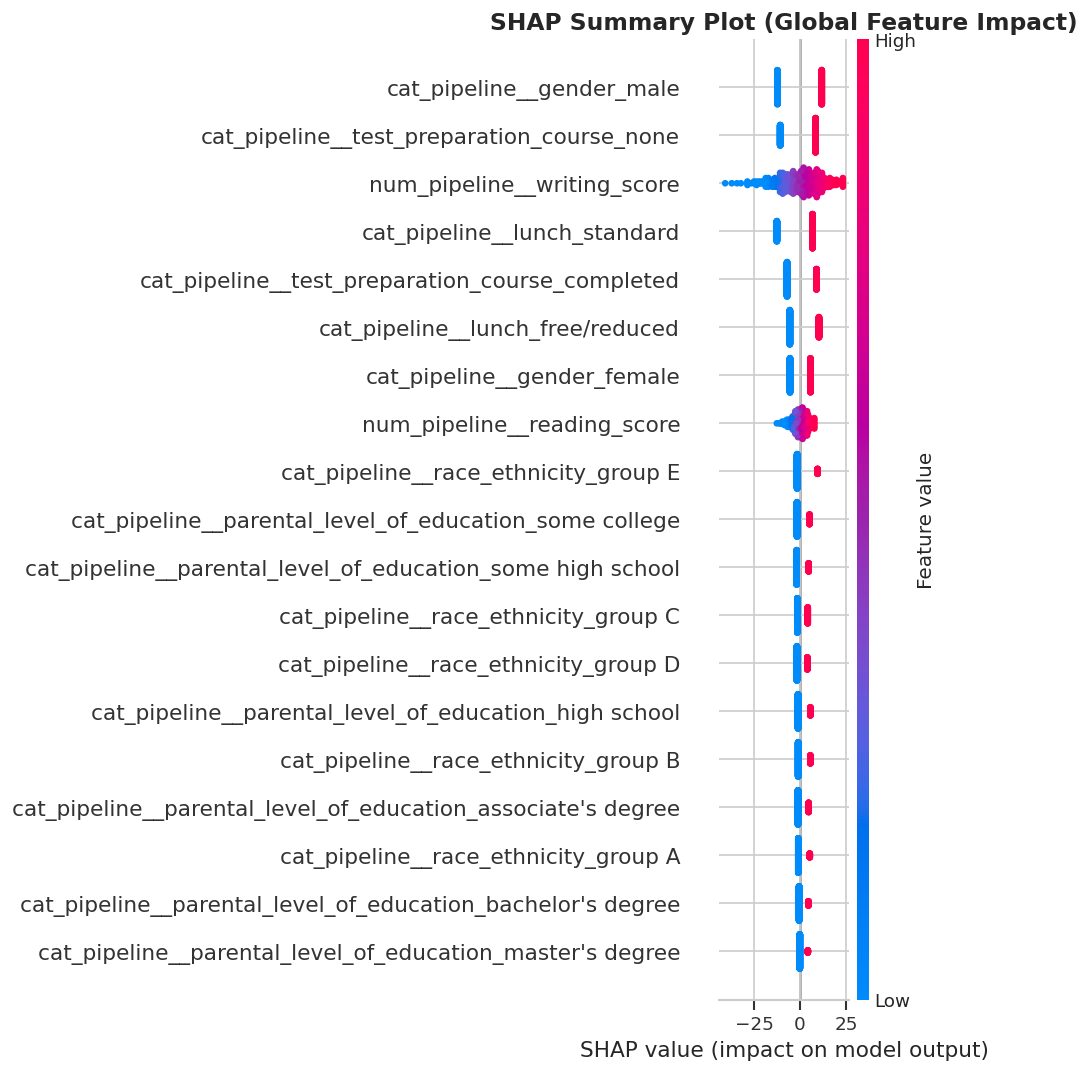

In [19]:
# 5.1 Beeswarm / Summary Plot (dot)
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="dot",
    show=False,
)
plt.title('SHAP Summary Plot (Global Feature Impact)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

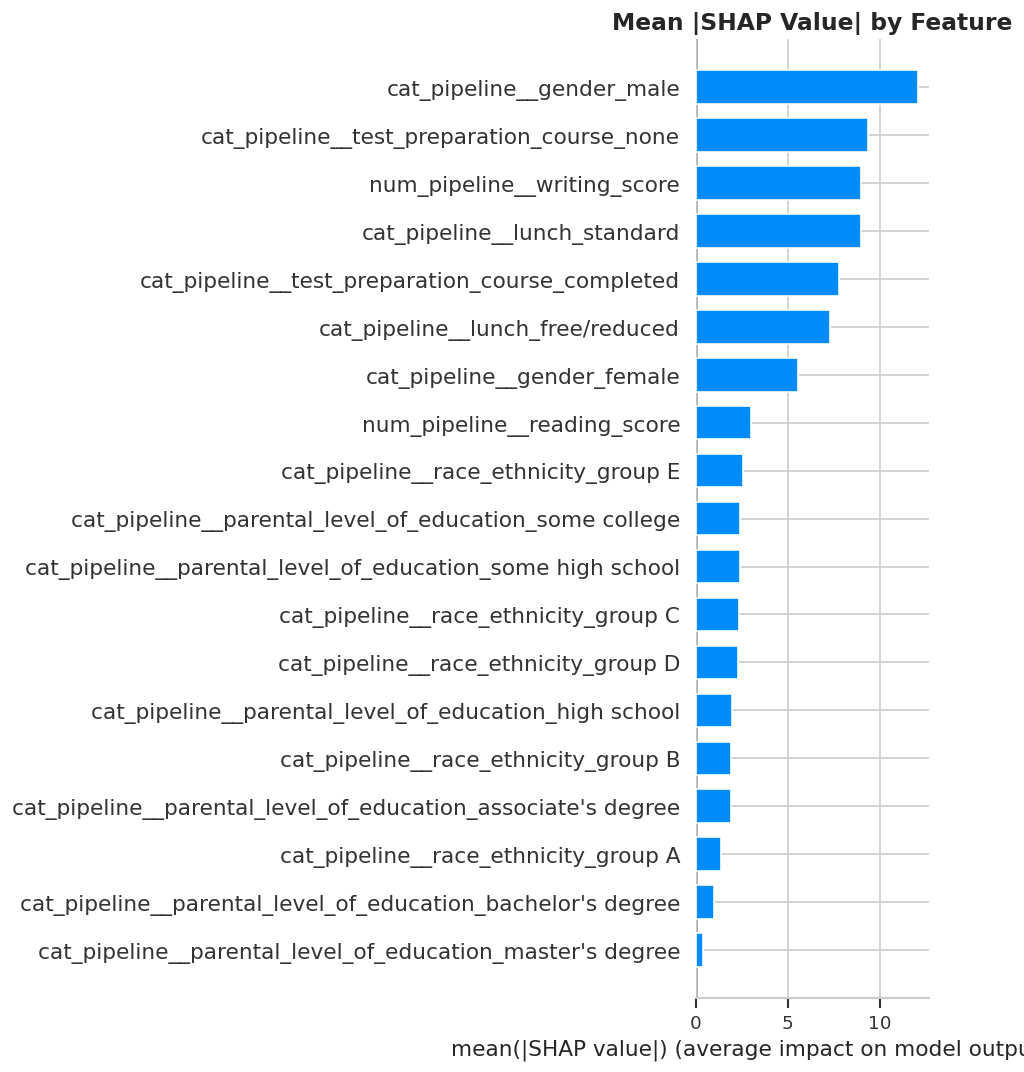

In [20]:
# 5.2 Bar plot: Mean |SHAP value| per feature
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=False,
)
plt.title('Mean |SHAP Value| by Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# 5.3 Feature importance table
importance_df = pd.DataFrame({
    'feature': feature_names,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("Top 10 Most Important Features:")
display(importance_df.head(10))

Top 10 Most Important Features:


,feature,mean_abs_shap
3,cat_pipeline__gender_male,12.065292
18,cat_pipeline__test_preparation_course_none,9.342044
0,num_pipeline__writing_score,8.990759
16,cat_pipeline__lunch_standard,8.961038
17,cat_pipeline__test_preparation_course_completed,7.760192
15,cat_pipeline__lunch_free/reduced,7.320087
2,cat_pipeline__gender_female,5.568831
1,num_pipeline__reading_score,2.992522
8,cat_pipeline__race_ethnicity_group E,2.560790
13,cat_pipeline__parental_level_of_education_some...,2.415789


---
## 6. Local Explanations <a id='6'></a>

Local explanations break down a **single prediction** to show how each feature contributed to pushing the predicted math score above or below the average (base value).

I examine three representative students:
1. **High performer** — top 10% math score
2. **Low performer** — bottom 10% math score
3. **Average student** — near median


High Performer (sample index 91) — Actual math score: 100


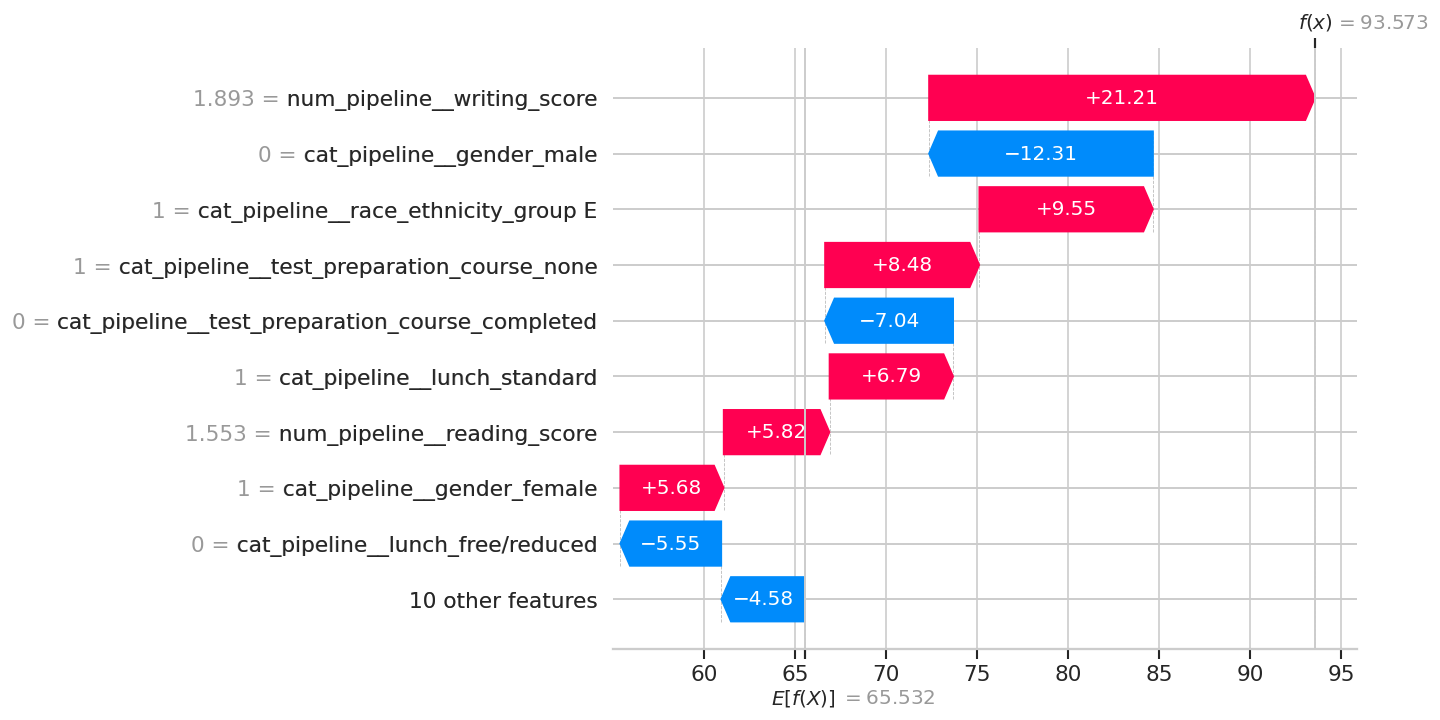


Low Performer (sample index 39) — Actual math score: 0


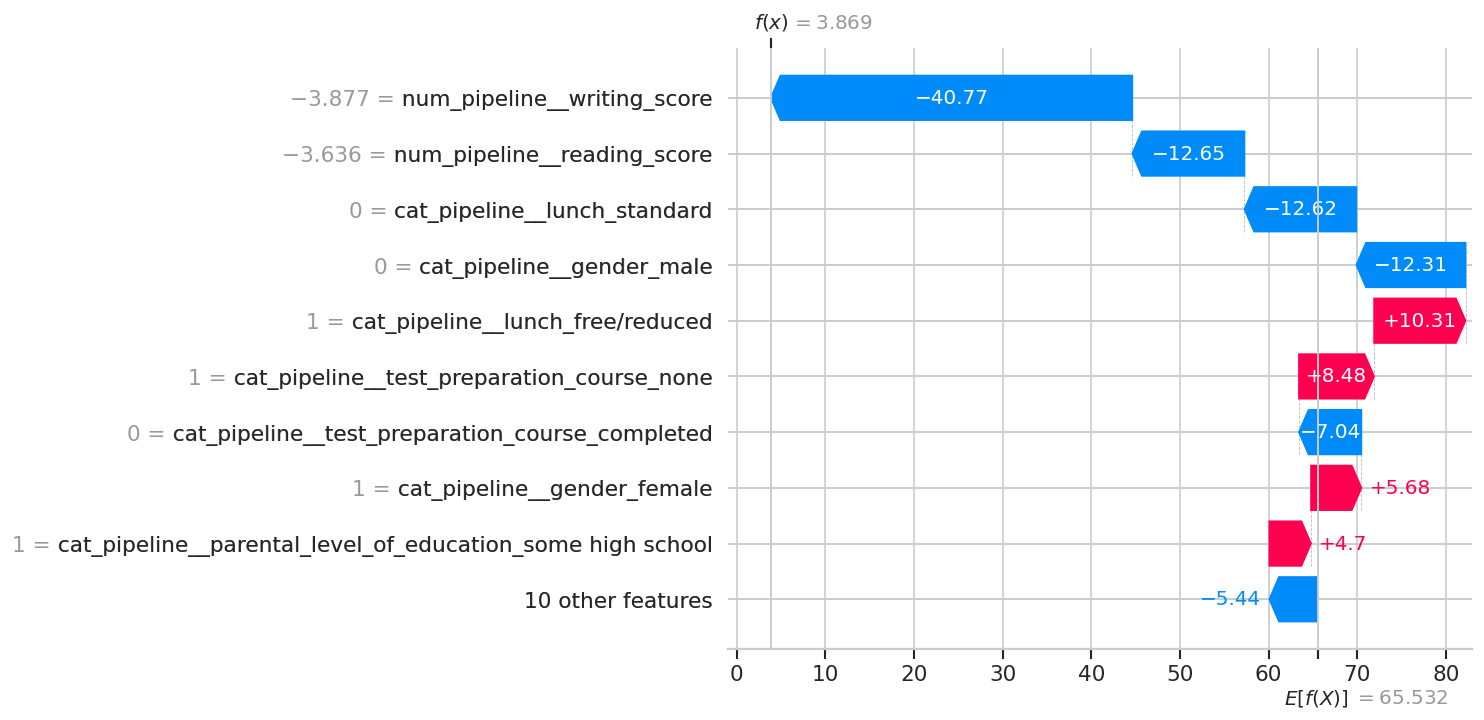


Average Student (sample index 181) — Actual math score: 66


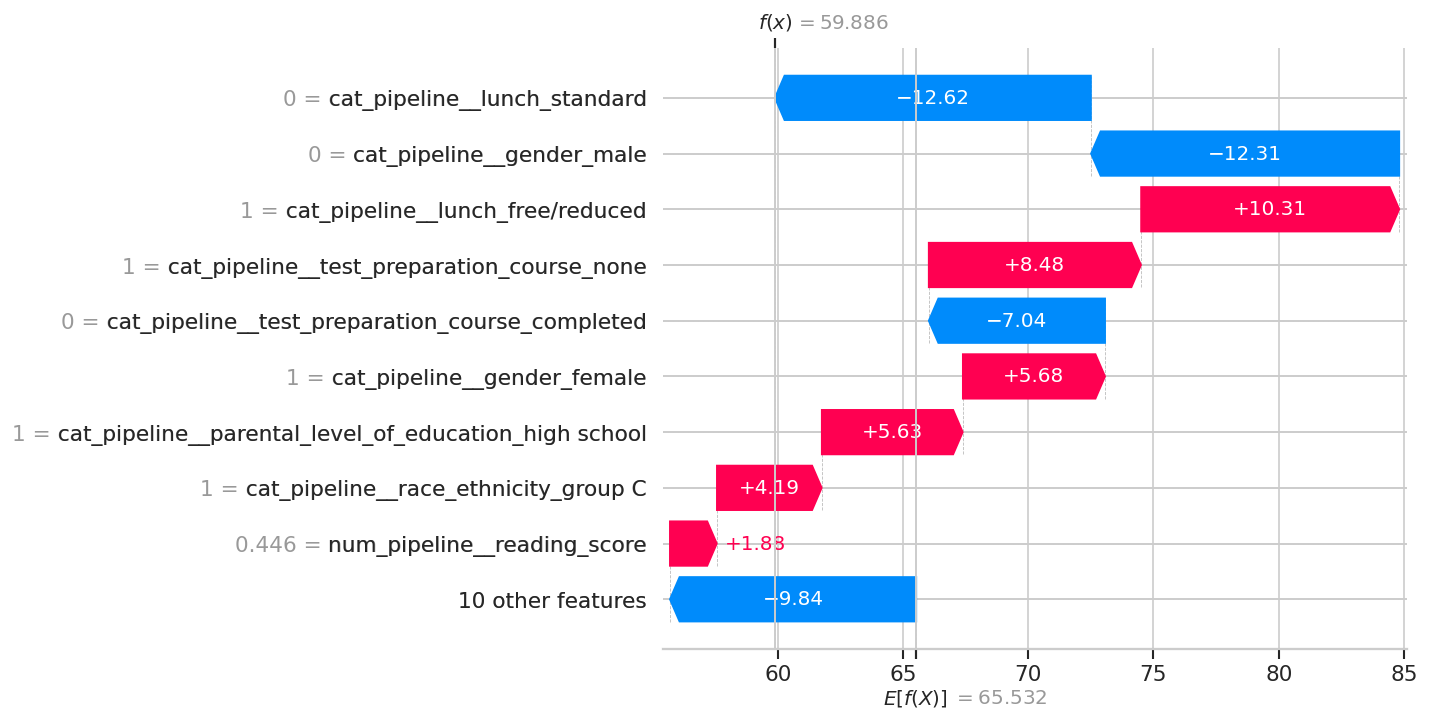

In [22]:
# Use the same random state as shap.sample for reproducible alignment
rng = np.random.RandomState(42)
sample_indices = rng.choice(len(X_transformed), size=SAMPLE_SIZE, replace=False)
X_sample = X_transformed[sample_indices]
y_sample = y.iloc[sample_indices].reset_index(drop=True)

# Pick percentiles from the aligned sample
sample_order = np.argsort(y_sample.values)
low_sidx = sample_order[0]
high_sidx = sample_order[-1]
avg_sidx = sample_order[len(sample_order) // 2]

profiles = {
    'High Performer': high_sidx,
    'Low Performer': low_sidx,
    'Average Student': avg_sidx
}

# Compute base value safely as a scalar
base_value = explainer.expected_value if hasattr(explainer, 'expected_value') else 0
if isinstance(base_value, np.ndarray):
    base_value = base_value.item() if base_value.size == 1 else base_value[0]

for label, sidx in profiles.items():
    print(f"\n{label} (sample index {sidx}) — Actual math score: {y_sample.iloc[sidx]}")
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[sidx],
            base_values=base_value,
            data=X_sample[sidx],
            feature_names=feature_names
        ),
        max_display=10
    )

---
## 7. Feature Deep Dive <a id='7'></a>

Dependence plots show how a single feature's value relates to its SHAP value, revealing non-linear relationships or interaction effects. I visualize the top 2 most important features.

Top 2 features for deep dive: ['cat_pipeline__gender_male', 'cat_pipeline__test_preparation_course_none']


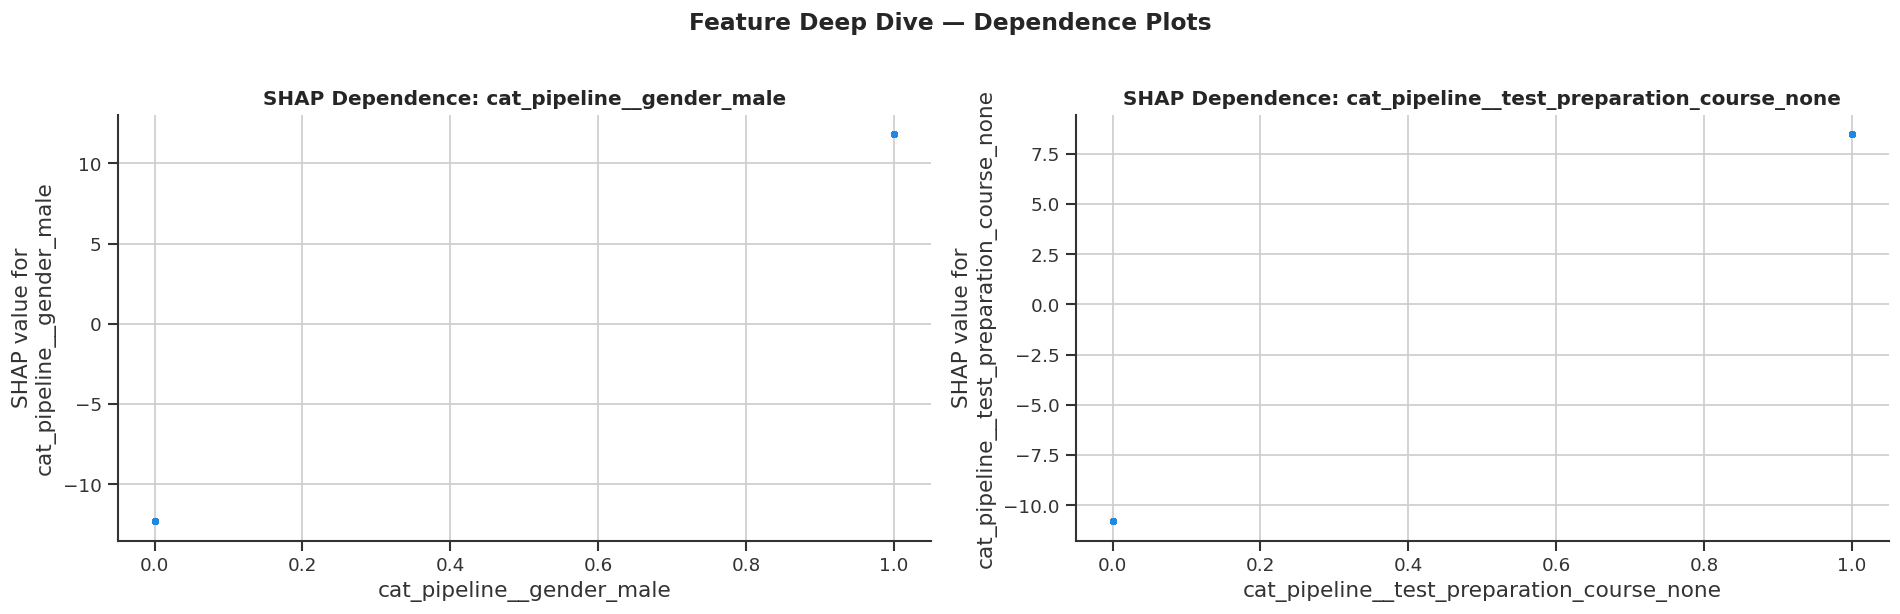

In [ ]:
# Identify top 2 features by mean |SHAP value|
top_features = importance_df.head(2)['feature'].tolist()
print(f"Top 2 features for deep dive: {top_features}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, feat in zip(axes, top_features):
    feat_idx = feature_names.index(feat)
    
    # Use reading_score as interaction feature if available, else None
    interaction = 'reading_score' if 'reading_score' in feature_names else None
    
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_sample,
        feature_names=feature_names,
        interaction_index=interaction,
        ax=ax,
        show=False
    )
    ax.set_title(f'SHAP Dependence: {feat}', fontsize=12, fontweight='bold')

plt.suptitle('Feature Deep Dive — Dependence Plots', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## Key Takeaways

**Overall Insights:**
- Global patterns show which features drive predictions across all students.
- Local breakdowns (waterfall plots) reveal exactly why a specific student received a high or low predicted score.
- Dependence plots expose non-linearities and potential interactions between features.

**Note:** If you retrain the model with different hyperparameters or a different algorithm, simply rerun this notebook, the explainer and visualizations will adapt automatically.